# Main Analysis: Cohen's Kappa (4 Models + Ensemble of 3)

This notebook builds the Cohen's kappa agreement plot against human consensus for:
- `gpt-5.4`
- `claude-sonnet-4-6`
- `gemini-3.1-pro-preview`
- `meta-llama/llama-4-scout-17b-16e-instruct`
- `ensemble_majority (3 models)`


In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
pd.set_option("display.max_columns", 120)

ROOT = Path('.')
DATA_DIR = ROOT / 'data'
CLEAN_DIR = ROOT / 'Clean output'
RESULTS_DIR = ROOT / 'results'
PLOT_DIR = ROOT / 'analysis_plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DIMENSIONS = ['coherence', 'signaling', 'label_accuracy', 'labeling']
LABEL_ORDER = ['Yes', 'No', 'N/A']

LLAMA_MODEL_NAME = 'meta-llama/llama-4-scout-17b-16e-instruct'
ENSEMBLE_MODEL_NAME = 'ensemble_majority'

MODEL_SPECS = {
    'gpt-5.4': {
        'patterns': ('pedagogical_eval_*.json',),
        'color': '#e41a1c',
        'display': 'gpt-5.4',
    },
    'claude-sonnet-4-6': {
        'patterns': ('pedagogical_eval_*.json',),
        'color': '#377eb8',
        'display': 'claude-sonnet-4-6',
    },
    'gemini-3.1-pro-preview': {
        'patterns': ('gemini*.json', 'pedagogical_eval_*.json'),
        'color': '#4daf4a',
        'display': 'gemini-3.1-pro',
    },
    LLAMA_MODEL_NAME: {
        'patterns': ('Llama_eval_*.json', 'pedagogical_eval_*.json'),
        'color': '#984ea3',
        'display': 'llama-4-scout-17b',
    },
}

ENSEMBLE_BASE_MODELS = ['gpt-5.4', 'claude-sonnet-4-6', 'gemini-3.1-pro-preview']

MODEL_COLORS = {k: v['color'] for k, v in MODEL_SPECS.items()}
MODEL_COLORS[ENSEMBLE_MODEL_NAME] = '#111111'

MODEL_DISPLAY_NAMES = {k: v['display'] for k, v in MODEL_SPECS.items()}
MODEL_DISPLAY_NAMES[ENSEMBLE_MODEL_NAME] = 'ensemble_majority (3 models)'

MODELS_ORDERED = [
    ENSEMBLE_MODEL_NAME,
    'claude-sonnet-4-6',
    'gemini-3.1-pro-preview',
    'gpt-5.4',
    LLAMA_MODEL_NAME,
]

def load_json(path: Path):
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def normalize_label(value):
    if value is None:
        return np.nan
    if isinstance(value, float) and np.isnan(value):
        return np.nan

    text = str(value).strip()
    if not text:
        return np.nan

    cleaned = text.upper().replace(' ', '')
    if cleaned in {'YES', 'Y'}:
        return 'Yes'
    if cleaned in {'NO', 'N'}:
        return 'No'
    if cleaned in {'N/A', 'NA', 'NOTAPPLICABLE', 'NOTAPPLICABILE'}:
        return 'N/A'
    return text

def majority_vote_label(values):
    votes = [v for v in values if v in LABEL_ORDER]
    if not votes:
        return np.nan

    counts = pd.Series(votes).value_counts()
    top_count = int(counts.iloc[0])
    tied = counts[counts == top_count].index.tolist()
    if top_count >= 2 and len(tied) == 1:
        return tied[0]
    return np.nan

def extract_llm_rows(records, model_name):
    rows = []
    for rec in records:
        if not isinstance(rec, dict):
            continue
        diagram_id = str(rec.get('diagram_id', '')).strip()
        rubric = rec.get('rubric')
        if not diagram_id or not isinstance(rubric, dict):
            continue

        for dim in DIMENSIONS:
            payload = rubric.get(dim)
            if not isinstance(payload, dict):
                continue
            value = normalize_label(payload.get('value'))
            if value not in LABEL_ORDER:
                continue
            rows.append(
                {
                    'diagram_id': diagram_id,
                    'model': model_name,
                    'dimension': dim,
                    'value': value,
                }
            )
    return pd.DataFrame(rows)

def cohens_kappa(y_true, y_pred, labels):
    y_true = list(y_true)
    y_pred = list(y_pred)
    n = len(y_true)
    if n == 0:
        return np.nan

    table = pd.crosstab(
        pd.Categorical(y_true, categories=labels),
        pd.Categorical(y_pred, categories=labels),
        dropna=False,
    ).reindex(index=labels, columns=labels, fill_value=0)

    observed = np.trace(table.values) / n
    row_marginals = table.sum(axis=1).to_numpy(dtype=float) / n
    col_marginals = table.sum(axis=0).to_numpy(dtype=float) / n
    expected = float(np.dot(row_marginals, col_marginals))

    if np.isclose(1.0 - expected, 0.0):
        return np.nan
    return (observed - expected) / (1.0 - expected)

def bootstrap_ci(y_true_arr, y_pred_arr, stat_fn, n_bootstrap=2000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true_arr)
    if n == 0:
        return np.nan, np.nan

    boot = np.empty(n_bootstrap, dtype=float)
    for b in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        boot[b] = stat_fn(y_true_arr[idx], y_pred_arr[idx])

    alpha = (100 - ci) / 2
    lo = float(np.nanpercentile(boot, alpha))
    hi = float(np.nanpercentile(boot, 100 - alpha))
    return lo, hi

def find_latest_model_file(model_name: str, patterns):
    candidate_dirs = [CLEAN_DIR, RESULTS_DIR]
    candidates = set()
    for directory in candidate_dirs:
        if not directory.exists():
            continue
        for pattern in patterns:
            candidates.update(directory.glob(pattern))

    for path in sorted(candidates, key=lambda p: p.stat().st_mtime, reverse=True):
        records = load_json(path)
        if not isinstance(records, list) or not records:
            continue

        sample_model = str(records[0].get('model', '')) if isinstance(records[0], dict) else ''
        if model_name in sample_model:
            return path

        head = records[:50]
        if any(isinstance(r, dict) and str(r.get('model', '')) == model_name for r in head):
            return path

    raise FileNotFoundError(f'No result file found for model: {model_name}')


In [4]:
human_raw = pd.DataFrame(load_json(DATA_DIR / 'human_ratings.json'))
qc_shared = pd.DataFrame(load_json(DATA_DIR / 'qc_adjudications.json'))

human_long = (
    human_raw.rename(columns={'original_csv_index': 'diagram_id'})
    [['diagram_id', 'rater', *DIMENSIONS]]
    .assign(diagram_id=lambda d: d['diagram_id'].astype(str))
    .melt(
        id_vars=['diagram_id', 'rater'],
        value_vars=DIMENSIONS,
        var_name='dimension',
        value_name='value',
    )
)
human_long['value'] = human_long['value'].map(normalize_label)
human_long = human_long[human_long['value'].isin(LABEL_ORDER)].copy()

qc_lookup = {}
if not qc_shared.empty:
    qc_shared = qc_shared.copy()
    qc_shared['diagram_id'] = qc_shared['original_csv_index'].astype(str)
    qc_shared['qc_final_value'] = qc_shared['qc_final_value'].map(normalize_label)
    for row in qc_shared.itertuples(index=False):
        if row.qc_final_value in LABEL_ORDER:
            qc_lookup[(str(row.diagram_id), row.dimension)] = row.qc_final_value

def resolve_human_group(group):
    values = [v for v in group['value'].tolist() if v in LABEL_ORDER]
    unique = set(values)
    if len(unique) == 1:
        return values[0]

    key = (group.name[0], group.name[1])
    if key in qc_lookup:
        return qc_lookup[key]

    if not values:
        return np.nan

    counts = pd.Series(values).value_counts()
    tied = counts[counts == counts.iloc[0]].index.tolist()
    for label in LABEL_ORDER:
        if label in tied:
            return label
    return tied[0]

consensus_rows = []
for (diagram_id, dimension), group in human_long.groupby(['diagram_id', 'dimension']):
    value = resolve_human_group(group)
    if value in LABEL_ORDER:
        consensus_rows.append(
            {
                'diagram_id': diagram_id,
                'dimension': dimension,
                'value': value,
            }
        )

human_consensus = pd.DataFrame(consensus_rows)

model_paths = {}
llm_frames = []
for model_name, spec in MODEL_SPECS.items():
    model_path = find_latest_model_file(model_name, spec['patterns'])
    model_paths[model_name] = model_path
    llm_frames.append(extract_llm_rows(load_json(model_path), model_name))

llm_long = pd.concat(llm_frames, ignore_index=True)

base_3_llm = llm_long[llm_long['model'].isin(ENSEMBLE_BASE_MODELS)].copy()
ensemble_rows = []
for (diagram_id, dimension), group in base_3_llm.groupby(['diagram_id', 'dimension']):
    voted_label = majority_vote_label(group['value'].tolist())
    if voted_label in LABEL_ORDER:
        ensemble_rows.append(
            {
                'diagram_id': diagram_id,
                'model': ENSEMBLE_MODEL_NAME,
                'dimension': dimension,
                'value': voted_label,
            }
        )

ensemble_long = pd.DataFrame(ensemble_rows)
if ensemble_long.empty:
    ensemble_long = pd.DataFrame(columns=['diagram_id', 'model', 'dimension', 'value'])

llm_eval_long = pd.concat([llm_long, ensemble_long], ignore_index=True)

print('Using model files:')
for model_name in MODELS_ORDERED:
    if model_name == ENSEMBLE_MODEL_NAME:
        continue
    print(f'  - {model_name}: {model_paths[model_name]}')


Using model files:
  - claude-sonnet-4-6: Clean output/pedagogical_eval_20260311_112236_804750.json
  - gemini-3.1-pro-preview: Clean output/gemini_pedagogical_eval_merged.json
  - gpt-5.4: Clean output/pedagogical_eval_20260311_104845_798292.json
  - meta-llama/llama-4-scout-17b-16e-instruct: Clean output/Llama_eval_20260316_151743_061636.json


In [5]:
comparison = (
    human_consensus.rename(columns={'value': 'human_value'})
    .merge(
        llm_eval_long.rename(columns={'value': 'llm_value'}),
        on=['diagram_id', 'dimension'],
        how='inner',
    )
)

comparison = comparison[
    comparison['human_value'].isin(LABEL_ORDER)
    & comparison['llm_value'].isin(LABEL_ORDER)
].copy()

def _kappa_stat(h, p):
    return cohens_kappa(h.tolist(), p.tolist(), LABEL_ORDER)

kappa_rows = []
for (model_name, dim), g in comparison.groupby(['model', 'dimension']):
    h = g['human_value'].to_numpy()
    p = g['llm_value'].to_numpy()
    kappa = cohens_kappa(h.tolist(), p.tolist(), LABEL_ORDER)
    kappa_lo, kappa_hi = bootstrap_ci(h, p, _kappa_stat)

    kappa_rows.append(
        {
            'model': model_name,
            'dimension': dim,
            'n': len(g),
            'cohens_kappa': kappa,
            'kappa_ci_lo': kappa_lo,
            'kappa_ci_hi': kappa_hi,
        }
    )

kappa_ci_df = (
    pd.DataFrame(kappa_rows)
    .sort_values(['dimension', 'model'])
    .reset_index(drop=True)
)

kappa_ci_df


,model,dimension,n,cohens_kappa,kappa_ci_lo,kappa_ci_hi
0,claude-sonnet-4-6,coherence,450,0.164811,0.050385,0.277321
1,ensemble_majority,coherence,448,0.194245,0.088013,0.301538
2,gemini-3.1-pro-preview,coherence,438,0.124974,0.034521,0.223802
3,gpt-5.4,coherence,450,0.148760,0.055686,0.242952
4,meta-llama/llama-4-scout-17b-16e-instruct,coherence,448,0.033993,-0.029412,0.150532
5,claude-sonnet-4-6,label_accuracy,450,0.612355,0.543906,0.675112
6,ensemble_majority,label_accuracy,449,0.605923,0.538937,0.669081
7,gemini-3.1-pro-preview,label_accuracy,438,0.554261,0.485744,0.618101
8,gpt-5.4,label_accuracy,450,0.570796,0.506215,0.633202
9,meta-llama/llama-4-scout-17b-16e-instruct,label_accuracy,448,0.616794,0.549913,0.681314


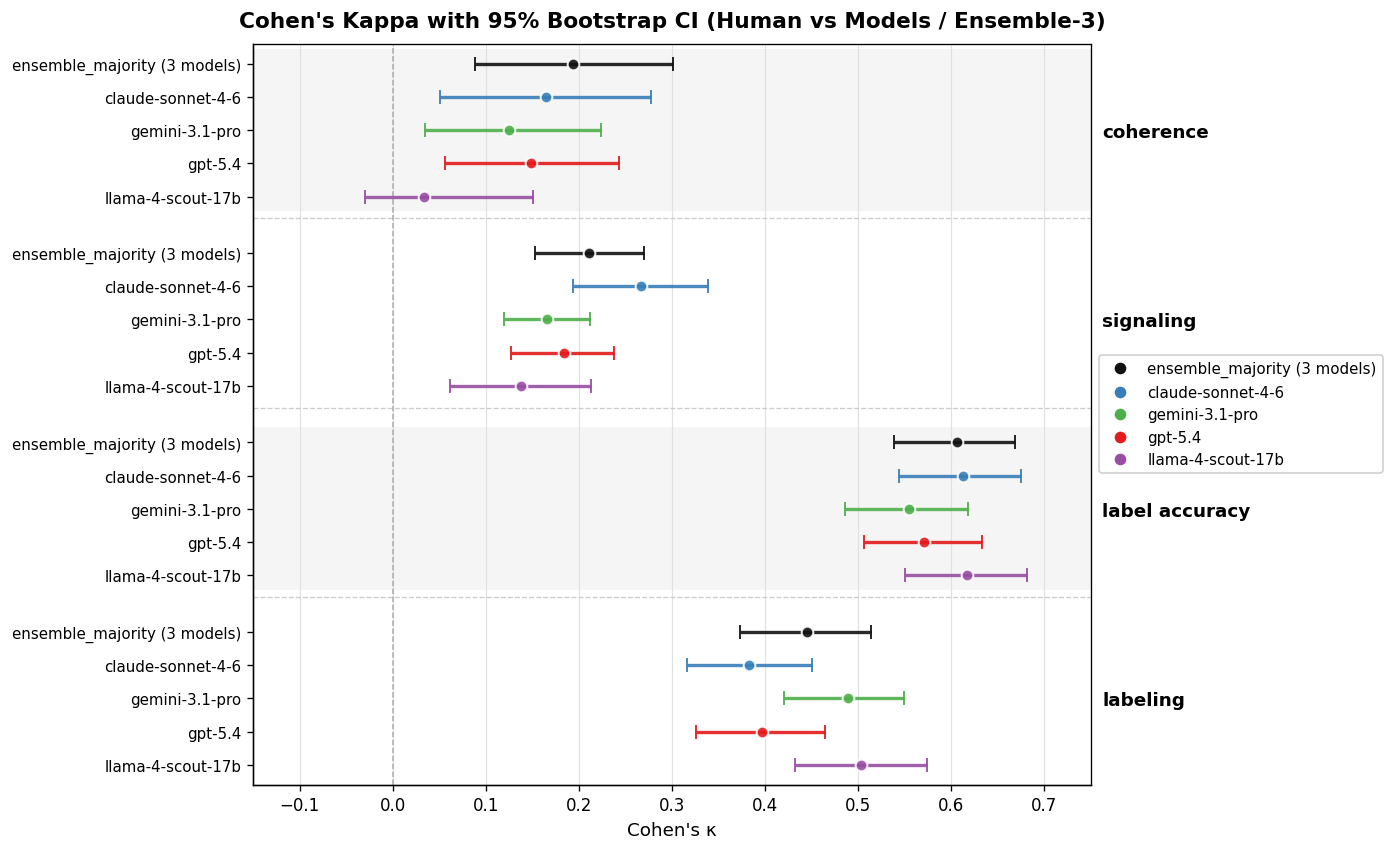

Saved: analysis_plots/ci_dotplot_kappa_all4_plus_ensemble3.png


In [6]:
def plot_kappa_ci_dotplot(ci_df, models_ordered, xlim=(-0.15, 0.75)):
    gap = 0.7
    y_pos = {}
    y_tick_pos, y_tick_labels = [], []
    dim_midpoints, dim_band_extents, dim_sep_y = {}, {}, []

    y = 0.0
    for d_idx, dim in enumerate(DIMENSIONS):
        if d_idx > 0:
            dim_sep_y.append(y - gap / 2)
            y += gap
        dim_start = y
        for model in models_ordered:
            y_pos[(dim, model)] = y
            y_tick_pos.append(y)
            y_tick_labels.append(MODEL_DISPLAY_NAMES.get(model, model))
            y += 1
        dim_midpoints[dim] = (dim_start + y - 1) / 2
        dim_band_extents[dim] = (dim_start - 0.45, y - 1 + 0.45)

    total_y = y - 1
    fig, ax = plt.subplots(figsize=(14, 7.2))

    for d_idx, dim in enumerate(DIMENSIONS):
        lo_y, hi_y = dim_band_extents[dim]
        if d_idx % 2 == 0:
            ax.axhspan(lo_y, hi_y, color='#f5f5f5', zorder=0, linewidth=0)

    for sep in dim_sep_y:
        ax.axhline(sep, color='#cccccc', linewidth=0.8, linestyle='--', zorder=1)

    if xlim[0] < 0 < xlim[1]:
        ax.axvline(0, color='#aaa', linewidth=0.9, linestyle='--', zorder=1)

    for dim in DIMENSIONS:
        for model in models_ordered:
            sub = ci_df[(ci_df['model'] == model) & (ci_df['dimension'] == dim)]
            if sub.empty:
                continue
            row = sub.iloc[0]
            color = MODEL_COLORS[model]
            xerr_lo = max(0.0, row['cohens_kappa'] - row['kappa_ci_lo'])
            xerr_hi = max(0.0, row['kappa_ci_hi'] - row['cohens_kappa'])
            ax.errorbar(
                row['cohens_kappa'],
                y_pos[(dim, model)],
                xerr=[[xerr_lo], [xerr_hi]],
                fmt='o',
                color=color,
                ecolor=color,
                elinewidth=2.0,
                capsize=4,
                capthick=1.5,
                markersize=7,
                markeredgecolor='white',
                markeredgewidth=1.2,
                alpha=0.9,
                zorder=3,
            )

    ax.set_yticks(y_tick_pos)
    ax.set_yticklabels(y_tick_labels, fontsize=9)
    ax.set_ylim(-0.6, total_y + 0.6)
    ax.invert_yaxis()

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    ax2.set_yticks([dim_midpoints[d] for d in DIMENSIONS])
    ax2.set_yticklabels([d.replace('_', ' ') for d in DIMENSIONS], fontsize=11, fontweight='bold')
    ax2.tick_params(right=False)

    ax.set_xlim(xlim)
    ax.set_xlabel("Cohen's κ", fontsize=11)
    ax.set_title("Cohen's Kappa with 95% Bootstrap CI (Human vs Models / Ensemble-3)", fontsize=13, fontweight='bold', pad=10)
    ax.grid(axis='x', color='#e0e0e0', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=MODEL_COLORS[m], markersize=8, label=MODEL_DISPLAY_NAMES.get(m, m))
        for m in models_ordered
    ]
    ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9, framealpha=0.9, borderaxespad=0.0)
    fig.tight_layout(rect=(0, 0, 0.84, 1))
    return fig

models_present = [m for m in MODELS_ORDERED if m in set(kappa_ci_df['model'].unique())]

fig_kappa = plot_kappa_ci_dotplot(kappa_ci_df, models_present, xlim=(-0.15, 0.75))
output_path = PLOT_DIR / 'ci_dotplot_kappa_all4_plus_ensemble3.png'
fig_kappa.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved: {output_path}')


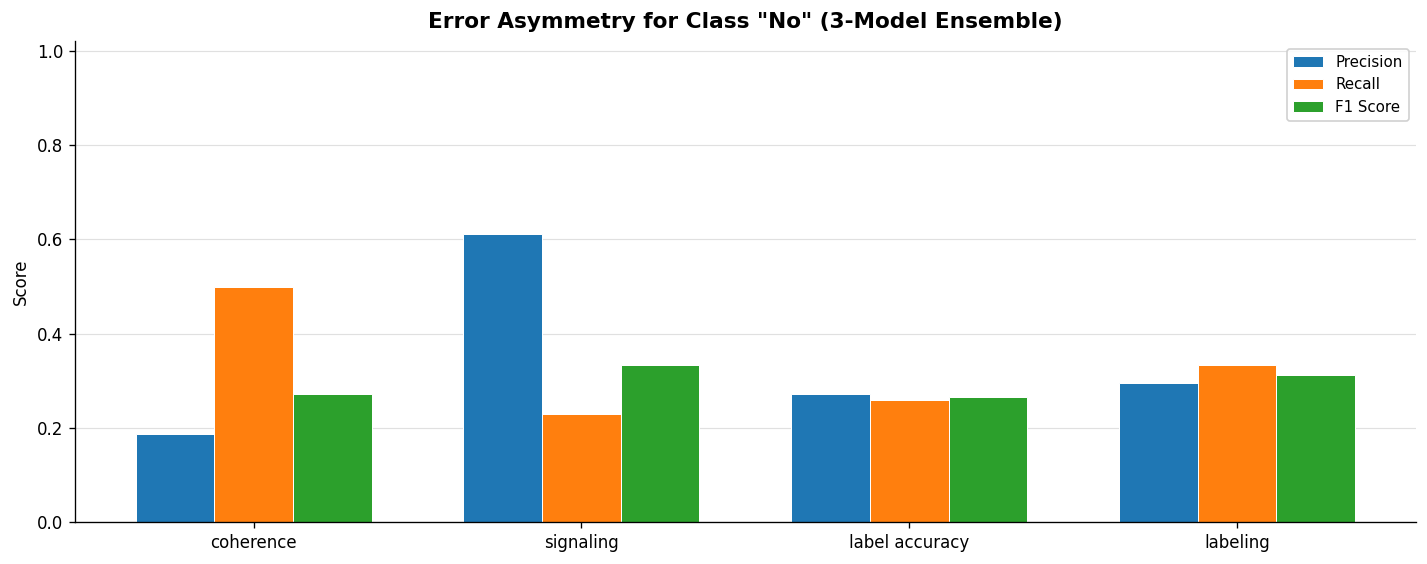

,dimension,n,tp_no,fp_no,fn_no,precision,recall,f1
0,coherence,448,15,65,15,0.187500,0.500000,0.272727
1,signaling,423,47,30,157,0.610390,0.230392,0.334520
2,label_accuracy,449,15,40,43,0.272727,0.258621,0.265487
3,labeling,443,28,67,56,0.294737,0.333333,0.312849


Saved: analysis_plots/error_asymmetry_no_class_ensemble3.png


In [8]:
# Error Asymmetry plot for class "No" (ensemble of 3 models)
ensemble_comp = comparison[comparison['model'] == ENSEMBLE_MODEL_NAME].copy()

if ensemble_comp.empty:
    raise ValueError('No ensemble comparison rows found. Run previous cells first.')

def no_class_metrics(y_true, y_pred, positive_label='No'):
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == positive_label and p == positive_label)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != positive_label and p == positive_label)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == positive_label and p != positive_label)

    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / (tp + fn) if (tp + fn) else np.nan
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan

    return {
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }

error_asymmetry_rows = []
for dim in DIMENSIONS:
    g = ensemble_comp[ensemble_comp['dimension'] == dim]
    if g.empty:
        continue

    y_true = g['human_value'].tolist()
    y_pred = g['llm_value'].tolist()
    m = no_class_metrics(y_true, y_pred, positive_label='No')

    error_asymmetry_rows.append(
        {
            'dimension': dim,
            'n': len(g),
            'tp_no': m['tp'],
            'fp_no': m['fp'],
            'fn_no': m['fn'],
            'precision': m['precision'],
            'recall': m['recall'],
            'f1': m['f1'],
        }
    )

error_asymmetry_df = pd.DataFrame(error_asymmetry_rows)
error_asymmetry_df['dimension'] = pd.Categorical(error_asymmetry_df['dimension'], categories=DIMENSIONS, ordered=True)
error_asymmetry_df = error_asymmetry_df.sort_values('dimension').reset_index(drop=True)

metrics_order = ['precision', 'recall', 'f1']
metric_labels = {'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1 Score'}
metric_colors = {'precision': '#1f77b4', 'recall': '#ff7f0e', 'f1': '#2ca02c'}

x = np.arange(len(error_asymmetry_df))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(12, 4.8))
for i, metric in enumerate(metrics_order):
    offset = (i - 1) * bar_width
    values = error_asymmetry_df[metric].to_numpy(dtype=float)
    ax.bar(
        x + offset,
        values,
        width=bar_width,
        label=metric_labels[metric],
        color=metric_colors[metric],
        edgecolor='white',
        linewidth=0.6,
    )

ax.set_xticks(x)
ax.set_xticklabels([d.replace('_', ' ') for d in error_asymmetry_df['dimension'].astype(str)], fontsize=10)
ax.set_ylim(0, 1.02)
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Error Asymmetry for Class "No" (3-Model Ensemble)', fontsize=13, fontweight='bold', pad=8)
ax.grid(axis='y', color='#e0e0e0', linewidth=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(framealpha=0.9, fontsize=9)
fig.tight_layout()

output_path = PLOT_DIR / 'error_asymmetry_no_class_ensemble3.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

display(error_asymmetry_df[['dimension', 'n', 'tp_no', 'fp_no', 'fn_no', 'precision', 'recall', 'f1']])
print(f'Saved: {output_path}')


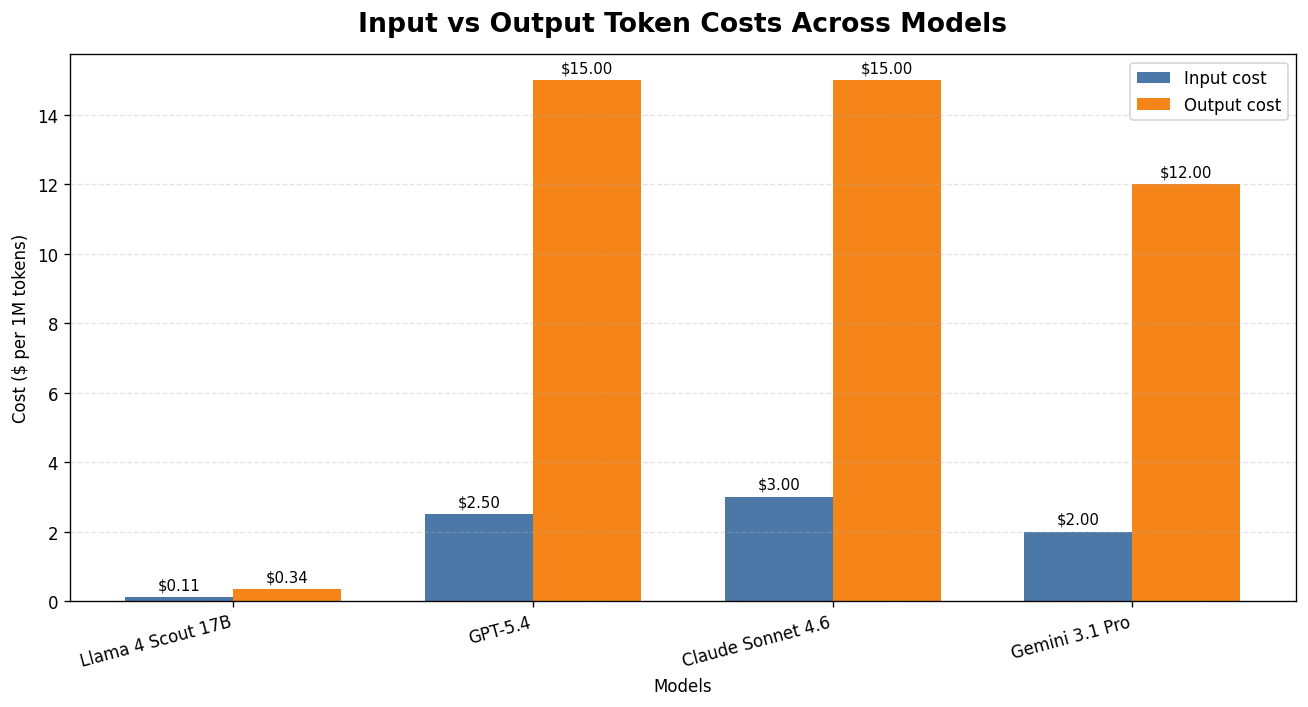

In [21]:
# Grouped bar chart: model pricing per 1M tokens
import numpy as np
import matplotlib.pyplot as plt

models = [
    "Llama 4 Scout 17B",
    "GPT-5.4",
    "Claude Sonnet 4.6",
    "Gemini 3.1 Pro",
]
input_costs = [0.11, 2.50, 3.00, 2.00]
output_costs = [0.34, 15.00, 15.00, 12.00]

x = np.arange(len(models))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6))
input_bars = ax.bar(x - width / 2, input_costs, width, label="Input cost", color="#4C78A8")
output_bars = ax.bar(x + width / 2, output_costs, width, label="Output cost", color="#F58518")

ax.set_xlabel("Models")
ax.set_ylabel("Cost ($ per 1M tokens)")
ax.set_title("Input vs Output Token Costs Across Models", fontsize=16, fontweight='bold', pad=14)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.35)

for bars in (input_bars, output_bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"${height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.tight_layout()
plt.show()


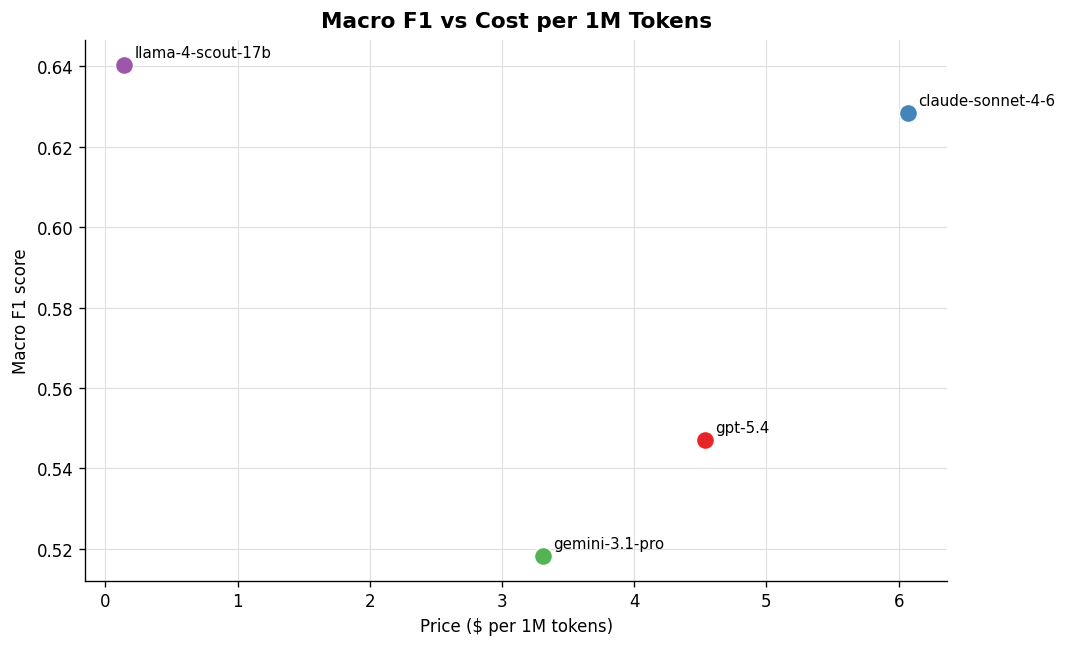

,display_model,macro_f1,price_per_1m_tokens,input_cost_per_1m,output_cost_per_1m,n
4,llama-4-scout-17b,0.640347,0.143820,0.11,0.34,1792
2,gemini-3.1-pro,0.518218,3.311546,2.00,12.00,1752
3,gpt-5.4,0.547092,4.537164,2.50,15.00,1800
0,claude-sonnet-4-6,0.628385,6.068802,3.00,15.00,1800


Saved: analysis_plots/macro_f1_vs_token_price_scatter.png
Note: ensemble_majority is excluded because it has no direct API price row.


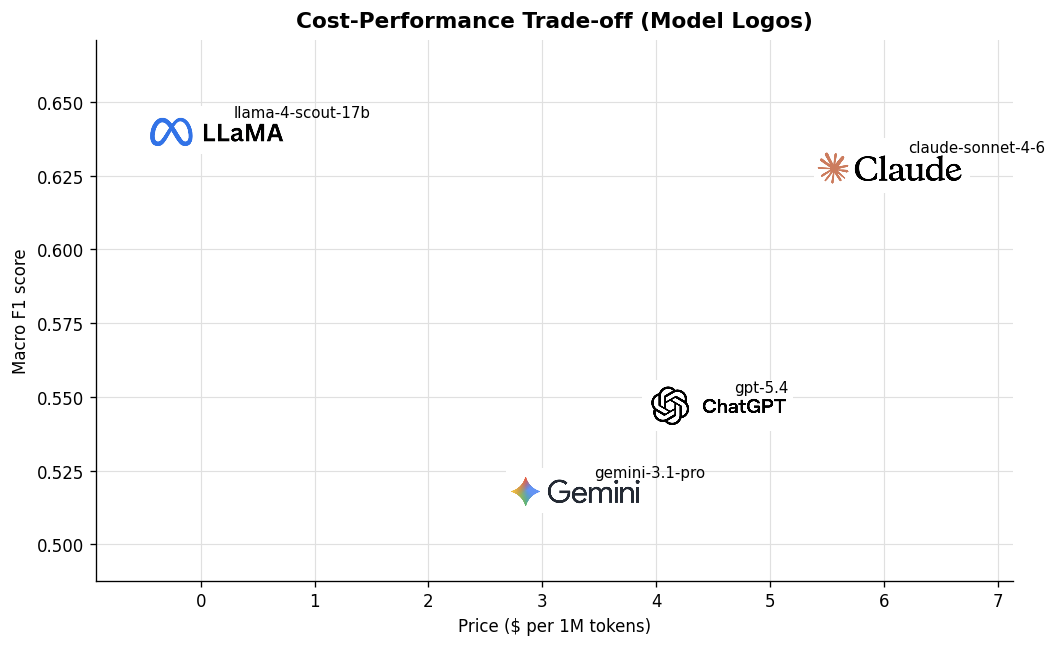

Saved: analysis_plots/macro_f1_vs_token_price_logos.png


In [18]:
# Scatter plot: Macro F1 score vs token price ($ per 1M tokens) per model
def macro_f1_score(y_true, y_pred, labels):
    f1_values = []
    for label in labels:
        tp = sum(1 for t, p in zip(y_true, y_pred) if t == label and p == label)
        fp = sum(1 for t, p in zip(y_true, y_pred) if t != label and p == label)
        fn = sum(1 for t, p in zip(y_true, y_pred) if t == label and p != label)

        precision = tp / (tp + fp) if (tp + fp) else np.nan
        recall = tp / (tp + fn) if (tp + fn) else np.nan
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else np.nan
        f1_values.append(f1)

    return float(np.nanmean(f1_values))

MODEL_PRICING_PER_1M = {
    'gpt-5.4': {'input_cost': 2.50, 'output_cost': 15.00},
    'claude-sonnet-4-6': {'input_cost': 3.00, 'output_cost': 15.00},
    'gemini-3.1-pro-preview': {'input_cost': 2.00, 'output_cost': 12.00},
    LLAMA_MODEL_NAME: {'input_cost': 0.11, 'output_cost': 0.34},
}

macro_f1_rows = []
for model_name, group in comparison.groupby('model'):
    macro_f1_rows.append(
        {
            'model': model_name,
            'macro_f1': macro_f1_score(group['human_value'].tolist(), group['llm_value'].tolist(), LABEL_ORDER),
            'n': len(group),
        }
    )

macro_f1_df = pd.DataFrame(macro_f1_rows)

price_rows = []
for model_name, model_path in model_paths.items():
    price_spec = MODEL_PRICING_PER_1M.get(model_name)
    if price_spec is None:
        continue

    records = load_json(model_path)
    total_input_tokens = 0.0
    total_output_tokens = 0.0

    for rec in records:
        if not isinstance(rec, dict):
            continue

        token_payload = rec.get('tokens')
        if not isinstance(token_payload, dict):
            continue

        try:
            input_tokens = float(token_payload.get('input_tokens'))
            output_tokens = float(token_payload.get('output_tokens'))
        except (TypeError, ValueError):
            continue

        if input_tokens < 0 or output_tokens < 0:
            continue

        total_input_tokens += input_tokens
        total_output_tokens += output_tokens

    total_tokens = total_input_tokens + total_output_tokens
    if total_tokens <= 0:
        effective_price_per_1m = np.nan
    else:
        effective_price_per_1m = (
            total_input_tokens * price_spec['input_cost']
            + total_output_tokens * price_spec['output_cost']
        ) / total_tokens

    price_rows.append(
        {
            'model': model_name,
            'price_per_1m_tokens': float(effective_price_per_1m) if not np.isnan(effective_price_per_1m) else np.nan,
            'input_cost_per_1m': price_spec['input_cost'],
            'output_cost_per_1m': price_spec['output_cost'],
            'total_input_tokens': total_input_tokens,
            'total_output_tokens': total_output_tokens,
        }
    )

price_df = pd.DataFrame(price_rows)

scatter_df = (
    macro_f1_df
    .merge(price_df, on='model', how='left')
    .dropna(subset=['price_per_1m_tokens', 'macro_f1'])
    .copy()
)

scatter_df['display_model'] = scatter_df['model'].map(lambda m: MODEL_DISPLAY_NAMES.get(m, m))

fig, ax = plt.subplots(figsize=(9, 5.5))
for row in scatter_df.itertuples(index=False):
    color = MODEL_COLORS.get(row.model, '#555555')
    ax.scatter(
        row.price_per_1m_tokens,
        row.macro_f1,
        s=120,
        color=color,
        edgecolor='white',
        linewidth=1.0,
        alpha=0.95,
    )
    ax.annotate(
        row.display_model,
        (row.price_per_1m_tokens, row.macro_f1),
        textcoords='offset points',
        xytext=(6, 5),
        fontsize=9,
    )

ax.set_xlabel('Price ($ per 1M tokens)')
ax.set_ylabel('Macro F1 score')
ax.set_title('Macro F1 vs Cost per 1M Tokens', fontsize=13, fontweight='bold', pad=8)
ax.grid(axis='both', color='#e0e0e0', linewidth=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

output_path = PLOT_DIR / 'macro_f1_vs_token_price_scatter.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

display(
    scatter_df[[
        'display_model',
        'macro_f1',
        'price_per_1m_tokens',
        'input_cost_per_1m',
        'output_cost_per_1m',
        'n',
    ]].sort_values('price_per_1m_tokens', ascending=True)
)
print(f'Saved: {output_path}')
print('Note: ensemble_majority is excluded because it has no direct API price row.')


# Additional plot: cost-performance trade-off with model logos
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

LOGO_DIR = ROOT / 'logos'
MODEL_LOGO_FILES = {
    'gpt-5.4': 'gpt 5.4.png',
    'claude-sonnet-4-6': 'claude.png',
    'gemini-3.1-pro-preview': 'Gemini.png',
    LLAMA_MODEL_NAME: 'meta Llama.png',
}

fig, ax = plt.subplots(figsize=(9, 5.5))

for row in scatter_df.itertuples(index=False):
    logo_filename = MODEL_LOGO_FILES.get(row.model)
    logo_path = LOGO_DIR / logo_filename if logo_filename else None

    if logo_path and logo_path.exists():
        logo_image = plt.imread(logo_path)
        logo_artist = AnnotationBbox(
            OffsetImage(logo_image, zoom=0.09),
            (row.price_per_1m_tokens, row.macro_f1),
            frameon=False,
            pad=0.0,
            zorder=4,
        )
        ax.add_artist(logo_artist)
    else:
        # Fallback marker for any model without a logo file.
        ax.scatter(
            row.price_per_1m_tokens,
            row.macro_f1,
            s=140,
            color=MODEL_COLORS.get(row.model, '#555555'),
            edgecolor='white',
            linewidth=1.0,
            alpha=0.95,
            zorder=4,
        )

    ax.annotate(
        row.display_model,
        (row.price_per_1m_tokens, row.macro_f1),
        textcoords='offset points',
        xytext=(10, 8),
        fontsize=9,
        zorder=5,
    )

x_min = float(scatter_df['price_per_1m_tokens'].min())
x_max = float(scatter_df['price_per_1m_tokens'].max())
y_min = float(scatter_df['macro_f1'].min())
y_max = float(scatter_df['macro_f1'].max())
x_pad = max((x_max - x_min) * 0.18, 0.05)
y_pad = max((y_max - y_min) * 0.25, 0.01)

ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))
ax.set_xlabel('Price ($ per 1M tokens)')
ax.set_ylabel('Macro F1 score')
ax.set_title('Cost-Performance Trade-off (Model Logos)', fontsize=13, fontweight='bold', pad=8)
ax.grid(axis='both', color='#e0e0e0', linewidth=0.7)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

logo_output_path = PLOT_DIR / 'macro_f1_vs_token_price_logos.png'
fig.savefig(logo_output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {logo_output_path}')


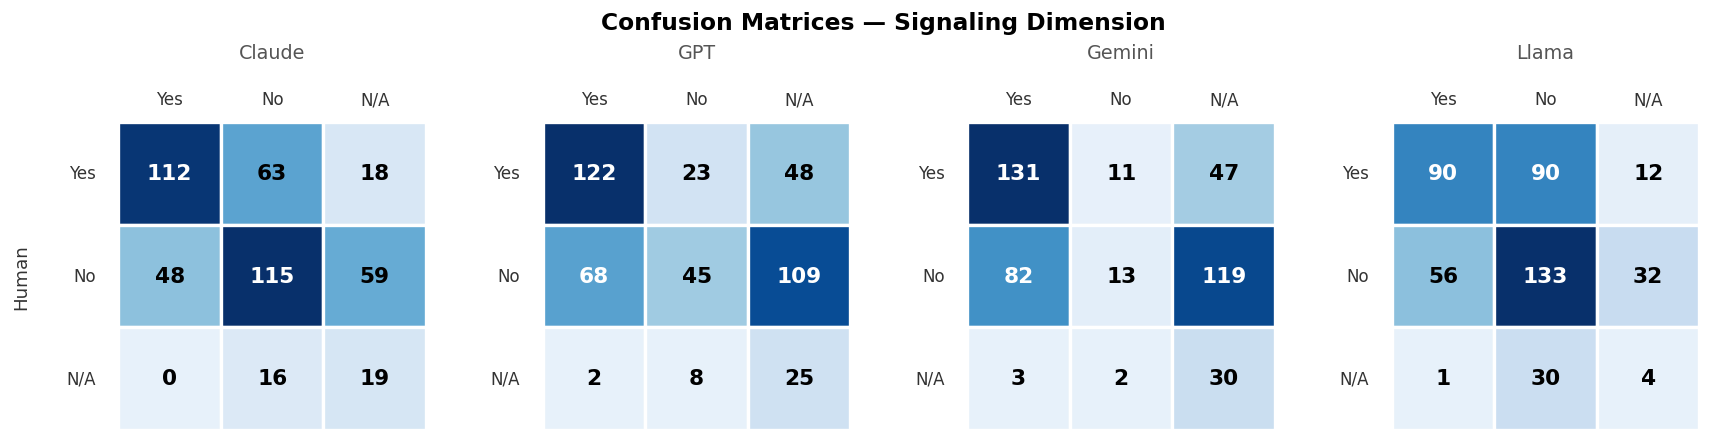

Saved → analysis_plots/confusion_matrices_signaling.png


In [24]:
# Confusion matrices for "signaling" dimension — Human vs each of the 4 models
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

LABEL_ORDER = ['Yes', 'No', 'N/A']

FOUR_MODELS = [
    'claude-sonnet-4-6',
    'gpt-5.4',
    'gemini-3.1-pro-preview',
    'meta-llama/llama-4-scout-17b-16e-instruct',
]

MODEL_SHORT_NAMES = {
    'claude-sonnet-4-6': 'Claude',
    'gpt-5.4': 'GPT',
    'gemini-3.1-pro-preview': 'Gemini',
    'meta-llama/llama-4-scout-17b-16e-instruct': 'Llama',
}

signaling_comp = comparison[comparison['dimension'] == 'signaling'].copy()

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
fig.subplots_adjust(wspace=0.38)

# Blue colormap matching the reference image
base_cmap = plt.cm.Blues

for ax, model_name in zip(axes, FOUR_MODELS):
    short = MODEL_SHORT_NAMES[model_name]
    sub = signaling_comp[signaling_comp['model'] == model_name]

    ct = pd.crosstab(
        pd.Categorical(sub['human_value'], categories=LABEL_ORDER),
        pd.Categorical(sub['llm_value'],   categories=LABEL_ORDER),
        dropna=False,
    ).reindex(index=LABEL_ORDER, columns=LABEL_ORDER, fill_value=0)

    mat = ct.values.astype(float)
    n_total = mat.sum()

    # Normalise for colour intensity (0–1 relative to max)
    norm = mcolors.Normalize(vmin=0, vmax=mat.max())

    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2.5)
    ax.set_aspect('equal')

    for row_i, true_label in enumerate(LABEL_ORDER):
        for col_j, pred_label in enumerate(LABEL_ORDER):
            val = int(mat[row_i, col_j])
            intensity = norm(val)
            # Slight blue background even for 0 cells
            bg_intensity = max(intensity, 0.08)
            color = base_cmap(bg_intensity)
            rect = plt.Rectangle(
                [col_j - 0.5, (2 - row_i) - 0.5], 1, 1,
                facecolor=color, edgecolor='white', linewidth=2,
            )
            ax.add_patch(rect)
            text_color = 'white' if intensity > 0.55 else 'black'
            ax.text(
                col_j, 2 - row_i, str(val),
                ha='center', va='center',
                fontsize=13, fontweight='bold', color=text_color,
            )

    # Column header (model name above grid)
    ax.text(1, 3.18, short, ha='center', va='center', fontsize=11.5,
            color='#555555', fontweight='normal')

    # Column tick labels (model / predicted)
    for col_j, lbl in enumerate(LABEL_ORDER):
        ax.text(col_j, 2.72, lbl, ha='center', va='center', fontsize=10, color='#333333')

    # Row tick labels (human / true) — placed to the left
    for row_i, lbl in enumerate(LABEL_ORDER):
        ax.text(-0.72, 2 - row_i, lbl, ha='right', va='center', fontsize=10, color='#333333')

    # Y-axis label "Human" on the first subplot only
    if model_name == FOUR_MODELS[0]:
        ax.text(-1.45, 1.0, 'Human', ha='center', va='center',
                fontsize=11, color='#333333', rotation=90)

#    ax.set_title(short, fontsize=12.5, fontweight='bold', pad=30)
    ax.axis('off')

fig.suptitle('Confusion Matrices — Signaling Dimension', fontsize=14, fontweight='bold', y=1.02)

plt.savefig(PLOT_DIR / 'confusion_matrices_signaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → analysis_plots/confusion_matrices_signaling.png')
